In [5]:
import pandas as pd
import numpy as np
import os


In [3]:
hnei_dataset = pd.read_csv("Battery_RUL.csv")

In [4]:
meta_path = 'cleaned_dataset/metadata.csv'
data_dir = 'cleaned_dataset/data/'
metadata = pd.read_csv(meta_path)

In [6]:
extracted_features = []

# 2. Process each battery
for battery_id, bat_group in metadata.groupby('battery_id'):
    cycle_index = 1
    
    charges = bat_group[bat_group['type'] == 'charge'].reset_index()
    discharges = bat_group[bat_group['type'] == 'discharge'].reset_index()
    
    max_cycles = min(len(charges), len(discharges))
    
    for i in range(max_cycles):
        charge_meta = charges.iloc[i]
        discharge_meta = discharges.iloc[i]
        
        # Load raw time-series CSVs
        charge_df = pd.read_csv(os.path.join(data_dir, charge_meta['filename']))
        discharge_df = pd.read_csv(os.path.join(data_dir, discharge_meta['filename']))
        
        # --- Feature Extraction ---
        
        # Min. Voltage Charg. (V)
        min_v_charge = charge_df['Voltage_measured'].min()
        
        # Charging time (s)
        charge_time = charge_df['Time'].max()
        
        # Time constant current (s) (NASA charges at 1.5A, tracking > 1.4A)
        cc_phase = charge_df[charge_df['Current_measured'] > 1.4]
        time_cc = cc_phase['Time'].max() - cc_phase['Time'].min() if not cc_phase.empty else 0
        
        # Time at 4.15V (s)
        high_v_phase = charge_df[charge_df['Voltage_measured'] >= 4.15]
        time_415v = high_v_phase['Time'].max() - high_v_phase['Time'].min() if not high_v_phase.empty else 0

        # Discharge Time (s)
        discharge_time = discharge_df['Time'].max()
        
        # Max. Voltage Dischar. (V)
        max_v_discharge = discharge_df['Voltage_measured'].max()
        
        # Decrement 3.6-3.4V (s)
        try:
            time_36 = discharge_df[discharge_df['Voltage_measured'] <= 3.6]['Time'].iloc[0]
            time_34 = discharge_df[discharge_df['Voltage_measured'] <= 3.4]['Time'].iloc[0]
            decrement_time = time_34 - time_36
        except IndexError:
            decrement_time = np.nan 

        # Append with EXACT HNEI headers
        extracted_features.append({
            'Battery_ID': battery_id,
            'Cycle_Index': cycle_index,
            'Discharge Time (s)': discharge_time,
            'Decrement 3.6-3.4V (s)': decrement_time,
            'Max. Voltage Dischar. (V)': max_v_discharge,
            'Min. Voltage Charg. (V)': min_v_charge,
            'Time at 4.15V (s)': time_415v,
            'Time constant current (s)': time_cc,
            'Charging time (s)': charge_time
        })
        
        cycle_index += 1

In [7]:
# 3. Create DataFrame and clean missing values
nasa_df = pd.DataFrame(extracted_features)
nasa_df.dropna(inplace=True)

# 4. Calculate RUL
# For each battery, find its max cycle index, then subtract the current cycle index
nasa_df['RUL'] = nasa_df.groupby('Battery_ID')['Cycle_Index'].transform('max') - nasa_df['Cycle_Index']

# (Optional) Drop the Battery_ID column if you strictly want to match the HNEI columns
nasa_df = nasa_df.drop(columns=['Battery_ID'])

In [8]:
print(nasa_df.head())

   Cycle_Index  Discharge Time (s)  Decrement 3.6-3.4V (s)  \
0            1            3690.234                1488.734   
1            2            3672.344                1472.266   
2            3            3651.641                1471.641   
3            4            3631.563                1472.532   
4            5            3629.172                1471.328   

   Max. Voltage Dischar. (V)  Min. Voltage Charg. (V)  Time at 4.15V (s)  \
0                   4.191492                 3.479394           7249.672   
1                   4.189773                 3.001951           7609.047   
2                   4.188187                 3.035879           7568.453   
3                   4.188461                 3.066145           7491.562   
4                   4.188299                 3.063766           7589.563   

   Time constant current (s)  Charging time (s)  RUL  
0                    760.250           7597.875  167  
1                   3367.391          10516.000  166  
2    

In [9]:
# save to csv called "nasa_battery_cycles.csv"
nasa_df.to_csv("nasa_battery_cycles.csv", index=False)

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load the data
hnei_df = pd.read_csv('Battery_RUL.csv')
nasa_df = pd.read_csv('nasa_battery_cycles.csv')

# 2. Clean HNEI Outliers 
# Dropping impossible values (like negative time or phases over 100,000 seconds)
time_cols = ['Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Time at 4.15V (s)', 
             'Time constant current (s)', 'Charging time (s)']

for col in time_cols:
    hnei_df = hnei_df[(hnei_df[col] >= 0) & (hnei_df[col] < 100000)]

# 3. Add Dataset Identifier (The Origin Flag)
hnei_df['Is_NASA'] = 0
nasa_df['Is_NASA'] = 1

# 4. Scale Features INDIVIDUALLY per dataset
feature_cols = ['Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 
                'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)']

scaler_hnei = StandardScaler()
hnei_df_scaled = hnei_df.copy()
hnei_df_scaled[feature_cols] = scaler_hnei.fit_transform(hnei_df[feature_cols])

scaler_nasa = StandardScaler()
nasa_df_scaled = nasa_df.copy()
nasa_df_scaled[feature_cols] = scaler_nasa.fit_transform(nasa_df[feature_cols])

# 5. Combine the Datasets
combined_df = pd.concat([hnei_df_scaled, nasa_df_scaled], ignore_index=True)

# Save the prepared dataset!
combined_df.to_csv('combined_scaled_battery_data.csv', index=False)

Generating sequences...
Training shapes: Seq=(14537, 10, 7), Static=(14537,), Y=(14537,)
Testing shapes: Seq=(2641, 10, 7), Static=(2641,), Y=(2641,)

Starting Training with Regularization...
Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 371792.7812 - mae: 517.4078 - val_loss: 1847.3132 - val_mae: 36.9604
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 206642.1094 - mae: 368.3838 - val_loss: 130826.1328 - val_mae: 359.5992
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 48545.4258 - mae: 158.5490 - val_loss: 104730.3984 - val_mae: 250.9141
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17247.9590 - mae: 97.7511 - val_loss: 93094.6562 - val_mae: 174.9174
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15028.7314 - mae: 92.1972 - val_loss: 90814.3438 - val_mae: 173.8836
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13990.0938 - mae: 89.3814 - val_loss: 88283.7266 - val_mae: 171.8867
Epoch 6: early stopping
Resto

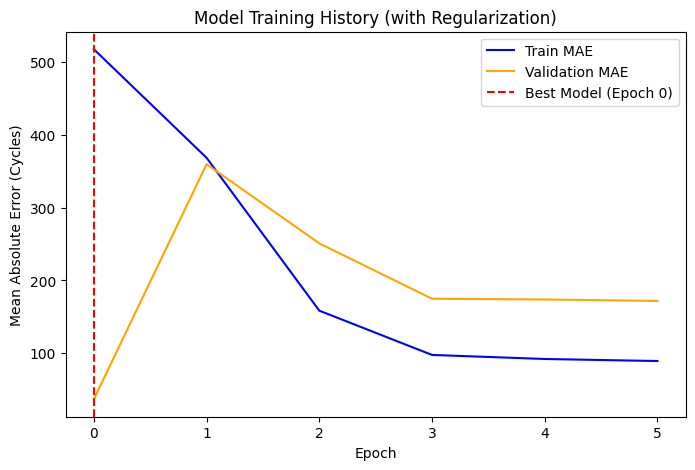

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 1. LOAD AND PREP DATA (WITH EPISODE TRACKING)
# ==========================================
df = pd.read_csv('combined_scaled_battery_data.csv')

# Because we dropped the Battery ID earlier, we need to reconstruct it so we don't 
# accidentally create a sequence that bridges the end of one battery and the start of another.
# We do this by tracking when the Cycle_Index drops (indicating a new battery started).
df['Battery_ID'] = (df['Cycle_Index'] < df['Cycle_Index'].shift(1)).cumsum()

feature_cols = ['Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 
                'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)']

# ==========================================
# 2. GROUPED TRAIN/TEST SPLIT
# ==========================================
# Split on Battery_ID so the model has to predict on entirely unseen batteries
unique_batteries = df['Battery_ID'].unique()
train_bats, test_bats = train_test_split(unique_batteries, test_size=0.2, random_state=42)

train_df = df[df['Battery_ID'].isin(train_bats)]
test_df = df[df['Battery_ID'].isin(test_bats)]

# ==========================================
# 3. SLIDING WINDOW GENERATOR
# ==========================================
def create_sequences(data_df, seq_length=10):
    """
    Slides a window of `seq_length` over the time-series.
    Returns:
      X_seq: (num_samples, seq_length, 7) - The dynamic features
      X_static: (num_samples, 1)          - The Is_NASA flag
      y: (num_samples,)                   - The RUL target
    """
    X_seq, X_static, y = [], [], []
    
    # Process one battery at a time
    for bat_id, group in data_df.groupby('Battery_ID'):
        
        # Extract features as numpy arrays
        dynamic_features = group[feature_cols].values
        static_flag = group['Is_NASA'].values
        targets = group['RUL'].values
        
        # Slide window
        for i in range(len(group) - seq_length):
            X_seq.append(dynamic_features[i : i + seq_length])
            
            # The static flag doesn't change over time, so we just grab the flag for this battery
            X_static.append(static_flag[0])
            
            # The target is the RUL at the END of the sequence
            y.append(targets[i + seq_length])
            
    return np.array(X_seq), np.array(X_static), np.array(y)

sequence_length = 10

# Generate arrays for training and testing
print("Generating sequences...")
X_train_seq, X_train_static, y_train = create_sequences(train_df, sequence_length)
X_test_seq, X_test_static, y_test = create_sequences(test_df, sequence_length)

print(f"Training shapes: Seq={X_train_seq.shape}, Static={X_train_static.shape}, Y={y_train.shape}")
print(f"Testing shapes: Seq={X_test_seq.shape}, Static={X_test_static.shape}, Y={y_test.shape}")

# ==========================================
# 4. BUILD THE REGULARIZED LATE FUSION ARCHITECTURE
# ==========================================
# Branch A: Time-Series (LSTM)
seq_input = Input(shape=(sequence_length, len(feature_cols)), name='time_series_input')
# Reduced capacity to prevent memorization
lstm_out = LSTM(32, activation='tanh', return_sequences=False)(seq_input)
# Randomly drop 20% of connections to force generalized learning
lstm_out = Dropout(0.2)(lstm_out) 

# Branch B: Static Flag (Is_NASA)
static_input = Input(shape=(1,), name='is_nasa_input')

# Fusion: Concatenate the LSTM output with the origin flag
merged = Concatenate()([lstm_out, static_input])

# Final dense layers with reduced capacity and more Dropout
dense_1 = Dense(16, activation='relu')(merged)
dense_1 = Dropout(0.2)(dense_1)
dense_2 = Dense(8, activation='relu')(dense_1)
output = Dense(1, activation='linear', name='rul_prediction')(dense_2)

# Compile model
model = Model(inputs=[seq_input, static_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# ==========================================
# 5. TRAIN WITH EARLY STOPPING
# ==========================================
# The EarlyStopping callback watches the validation MAE.
# patience=5 means it will wait 5 epochs after the lowest point to make sure 
# it's not just a temporary bump before halting.
early_stop = EarlyStopping(
    monitor='val_mae', 
    patience=5, 
    restore_best_weights=True, 
    verbose=1
)

print("\nStarting Training with Regularization...")
history = model.fit(
    x=[X_train_seq, X_train_static],
    y=y_train,
    validation_split=0.1,             
    epochs=50, # We can leave this at 50, early_stop will cut it off when appropriate
    batch_size=64,
    callbacks=[early_stop], # Activate the early stopping monitor
    verbose=1
)
# ==========================================
# 6. TEST AND EVALUATE
# ==========================================
print("\nEvaluating on unseen Test Batteries...")
test_loss, test_mae = model.evaluate(
    x=[X_test_seq, X_test_static],
    y=y_test,
    verbose=0
)

print(f"Test Mean Absolute Error (MAE): {test_mae:.2f} Cycles")

# Plot the training history to see the effect of Regularization
plt.figure(figsize=(8, 5))
plt.plot(history.history['mae'], label='Train MAE', color='blue')
plt.plot(history.history['val_mae'], label='Validation MAE', color='orange')

# If early stopping was triggered, draw a line at the best epoch
# Note: The 'best' epoch is the stopped epoch minus the patience we set (5)
if early_stop.stopped_epoch > 0:
    best_epoch = early_stop.stopped_epoch - early_stop.patience
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch})')

plt.title('Model Training History (with Regularization)')
plt.ylabel('Mean Absolute Error (Cycles)')
plt.xlabel('Epoch')
plt.legend()
plt.show()